<a href="https://colab.research.google.com/github/JoaoMAraujoJr/Resolu-es-Atividades-Aprendizado-de-Maquina-Supervisionado/blob/main/12_Embeddings_Analysis_resolu%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Embeddings e Redução da Dimensionalidade

**Objetivo.** Dado um conjunto de textos, gerar embeddings com BERT e investigar a estrutura dos dados via PCA, t-SNE e UMAP. Em seguida, identificar clusters e relacioná-los a categorias semânticas.

In [ ]:
sentences = [
    'I swap butter for olive oil in many recipes.',
    'Canberra is the capital of Australia.',
    'Ottawa is the capital city of Canada.',
    'Paris is the most populated city in France.',
    'Tokyo is among the most populous metropolitan areas worldwide.',
    'I prefer my coffee with no sugar and a splash of milk.',
    'The recipe for pasta carbonara is simple.',
    'A pinch of salt enhances sweetness in desserts.',
    'Alignment techniques reduce harmful outputs.',
    'Explainable AI highlights salient features for decisions.',
    'Transformer models enable long-range language dependencies.',
    'Black swan events stress-test portfolio resilience.',
    'The Sahara Desert spans much of North Africa.',
    'Inflation erodes real purchasing power of cash.',
    'Aromatics like garlic and onion build flavor early.',
    'Value stocks trade at lower multiples relative to fundamentals.',
    'Quantization reduces memory with minimal accuracy loss.',
    'Tax-loss harvesting offsets capital gains.',
    'Investing in technology can be risky.',
    'Fermented foods add acidity and complexity.',
    'Marinating tofu improves texture and taste.',
    'Vector databases power semantic search at scale.',
    'Distillation transfers knowledge from large to small models.',
    'The Great Barrier Reef lies off Australia’s northeast coast.',
    'Retrieval-augmented generation grounds answers in sources.',
    'Iceland lies on the Mid-Atlantic Ridge.',
    'The Baltic states border the eastern Baltic Sea.',
    'Multimodal learning aligns text with images and audio.',
    'Risk tolerance should guide position sizing.',
    'Time in the market beats timing the market.',
    'Behavioral biases can derail investment plans.',
    'Reinforcement learning fine-tunes policies from human feedback.',
    'Edge AI runs models under strict latency constraints.',
    'Deglazing lifts browned bits to make pan sauces.',
    'Tempering chocolate stabilizes cocoa butter crystals.',
    'What is the capital of France?',
    'Johannesburg is a major city but not South Africa’s capital.',
    'The Danube passes through multiple European capitals.',
    'The Amazon River carries one of the largest water volumes on Earth.',
    'A healthy emergency fund reduces forced selling.',
    'I batch-cook grains for quick lunches.',
    'Resting steak helps redistribute the juices.',
    'The Atacama is one of the driest deserts on the planet.',
    'Liquidity risk rises when trading volumes are thin.',
    'Mount Everest is the highest peak above sea level.',
    'Graph neural networks capture relational structure.',
    'Sourdough starter needs regular feedings to stay active.',
    'The stock market experienced a drop today.',
    'Umami-rich ingredients deepen savory dishes.',
    'Al dente pasta retains a slight bite after cooking.',
    'Rebalancing restores target asset allocation.',
    'Continual learning mitigates catastrophic forgetting.',
    'Bond duration measures sensitivity to interest-rate changes.',
    'Diffusion models synthesize high-fidelity images.',
    'Expense ratios compound against long-term returns.',
    'Self-supervised pretraining reduces labeled data needs.',
    'What country contains the city of Kyoto?',
    'Stir-frying requires high heat and constant movement.',
    'Covered calls generate income with capped upside.',
    'The Nile flows northward into the Mediterranean Sea.',
    'Causal inference distinguishes correlation from effect.',
    'Prompt engineering steers generative behavior reliably.',
    'Few-shot prompting improves generalization on new tasks.',
    'Growth investing prioritizes earnings expansion.',
    'The Alps stretch across several central European countries.',
    'The Andes form a continuous mountain range along South America.',
    'I cook vegetarian meals on weekdays to simplify planning.',
    'Natural language processing has advanced greatly.',
    'Sous-vide delivers precise temperature control.',
    'Diversification reduces idiosyncratic risk across holdings.',
    'Sharpe ratio evaluates risk-adjusted performance.',
    'Artificial intelligence is transforming the world.',
    'Credit spreads widen during economic uncertainty.',
    'Emerging markets add diversification but higher volatility.',
    'Mise en place speeds up weeknight cooking.',
    'The Caspian Sea is a landlocked body of water.',
    'Evaluation with benchmarks must avoid data leakage.',
    'Cairo sits along the Nile River delta.',
    'Federated learning trains models without centralizing data.',
    'Lagos is Nigeria’s largest city by population.',
    'Dollar-cost averaging smooths entry price over time.',
    'LoRA adapters enable efficient fine-tuning.',
    'I keep a jar of homemade pesto for pasta.',
    'New Delhi serves as the seat of India’s government.',
    'I like to cook Italian dishes on Sundays.',
    'Roasting vegetables caramelizes natural sugars.',
    'ETFs provide broad market exposure with intraday liquidity.',
    'Proofing time affects a bread’s crumb structure.'
    ]


## Predição dos Embeddings

Utilize o modelo BERT pré-treinado para gerar embeddings de todos os textos fornecidos.  
O objetivo é obter uma matriz `X` com formato **(N, dim)**, onde **N** é o número de textos e **dim** é a dimensionalidade dos vetores de embedding.

In [ ]:
!pip install umap-learn
import torch
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer


#carregando o modelo 'sentence-transformers/all-MiniLM-L6-v2'
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
X = model.encode(sentences, convert_to_numpy=True)

print(f"formato da matrix de embedding: {X.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Shape of the embedding matrix X: (88, 384)


## PCA

Aplique **PCA (Principal Component Analysis)** para projetar os embeddings em duas dimensões e visualizar a estrutura global dos dados.  
O PCA ajuda a capturar as direções de maior variância e pode indicar agrupamentos lineares.

**Tarefas:**
- Reduza a dimensionalidade dos embeddings para 2 componentes principais.  
- Plote os pontos resultantes com `matplotlib`, identificando possíveis agrupamentos.  
- Analise qualitativamente se há separação entre textos de temas distintos.

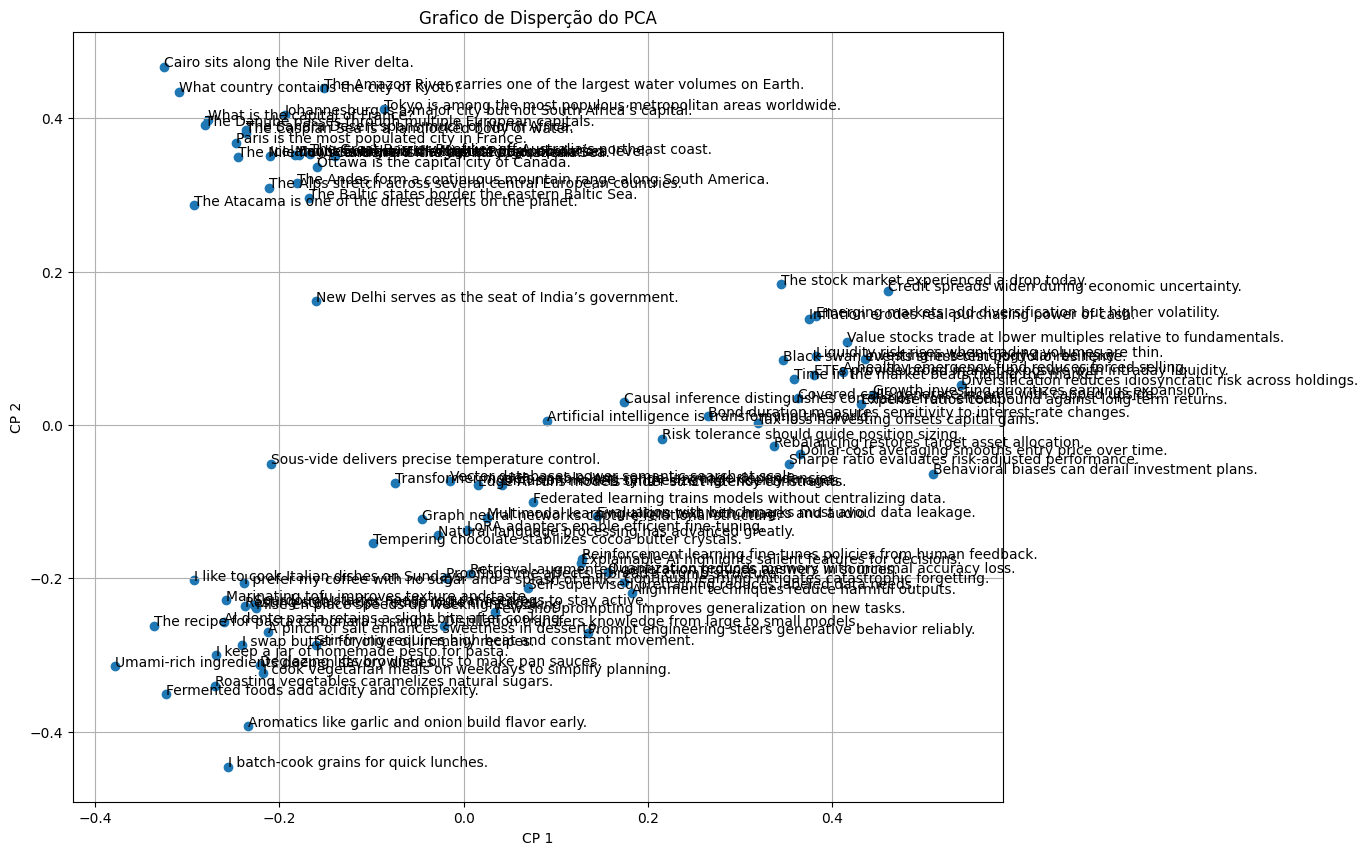

In [ ]:

from sklearn.decomposition import PCA

#PCA
X_pca = PCA(n_components=2).fit_transform(X)

#plot
plt.figure(figsize=(12, 10))
plt.scatter(X_pca[:, 0], X_pca[:, 1])

for i, (x, y) in enumerate(X_pca):
  plt.text(x, y, sentences[i],ha='left',size=10,color='black',alpha=1.0,weight='normal')

plt.title('Grafico de Disperção do PCA')
plt.xlabel('CP 1')
plt.ylabel('CP 2')
plt.grid(True)
plt.show()

### Análise do Gráfico de Dispersão

A projeção gerada pelo PCA evidencia uma separação não apenas distributiva, mas também semântica entre os dados, permitindo a identificação de quatro clusters principais, três relativamente próximos entre si e um mais afastado.

* Cluster 1: O primeiro cluster concentra conteúdos de natureza geográfica e de conhecimento geral, reunindo referências a cidades, países, rios, desertos e outras características naturais. Esse cluster apresenta uma estrutura relativamente compacta e mais isolada em relação aos demais.

* Cluster 2: O segundo é fortemente associado a conceitos de finanças e economia, incluindo termos relacionados a mercado financeiro, risco e investimentos.

* Cluster 3: O terceiro grupo está relacionado a conceitos de aprendizado de máquina, prompts de inteligência artificial e grandes modelos de linguagem.

* Cluster 4: O quarto cluster é predominantemente composto por conteúdos ligados à culinária, incluindo processos de preparação de alimentos, técnicas de cozinha, ingredientes e descrições de receitas.

Além desses quatro clusters principais, também são observadas regiões intermediárias com instâncias de sobreposição entre temas distinto e outliers que não pertencem a nenhum grupo em especifico.

## t-SNE

Use **t-SNE (t-distributed Stochastic Neighbor Embedding)** para investigar a estrutura local dos dados.  
Diferente do PCA, o t-SNE tenta preservar vizinhanças locais e pode revelar grupos mais sutis.

**Tarefas:**
- Reduza os embeddings para 2D usando `TSNE` do `scikit-learn`.  
- Ajuste parâmetros como `perplexity` e `learning_rate` para comparar resultados.  
- Visualize o mapa e observe se os textos semelhantes ficam próximos.

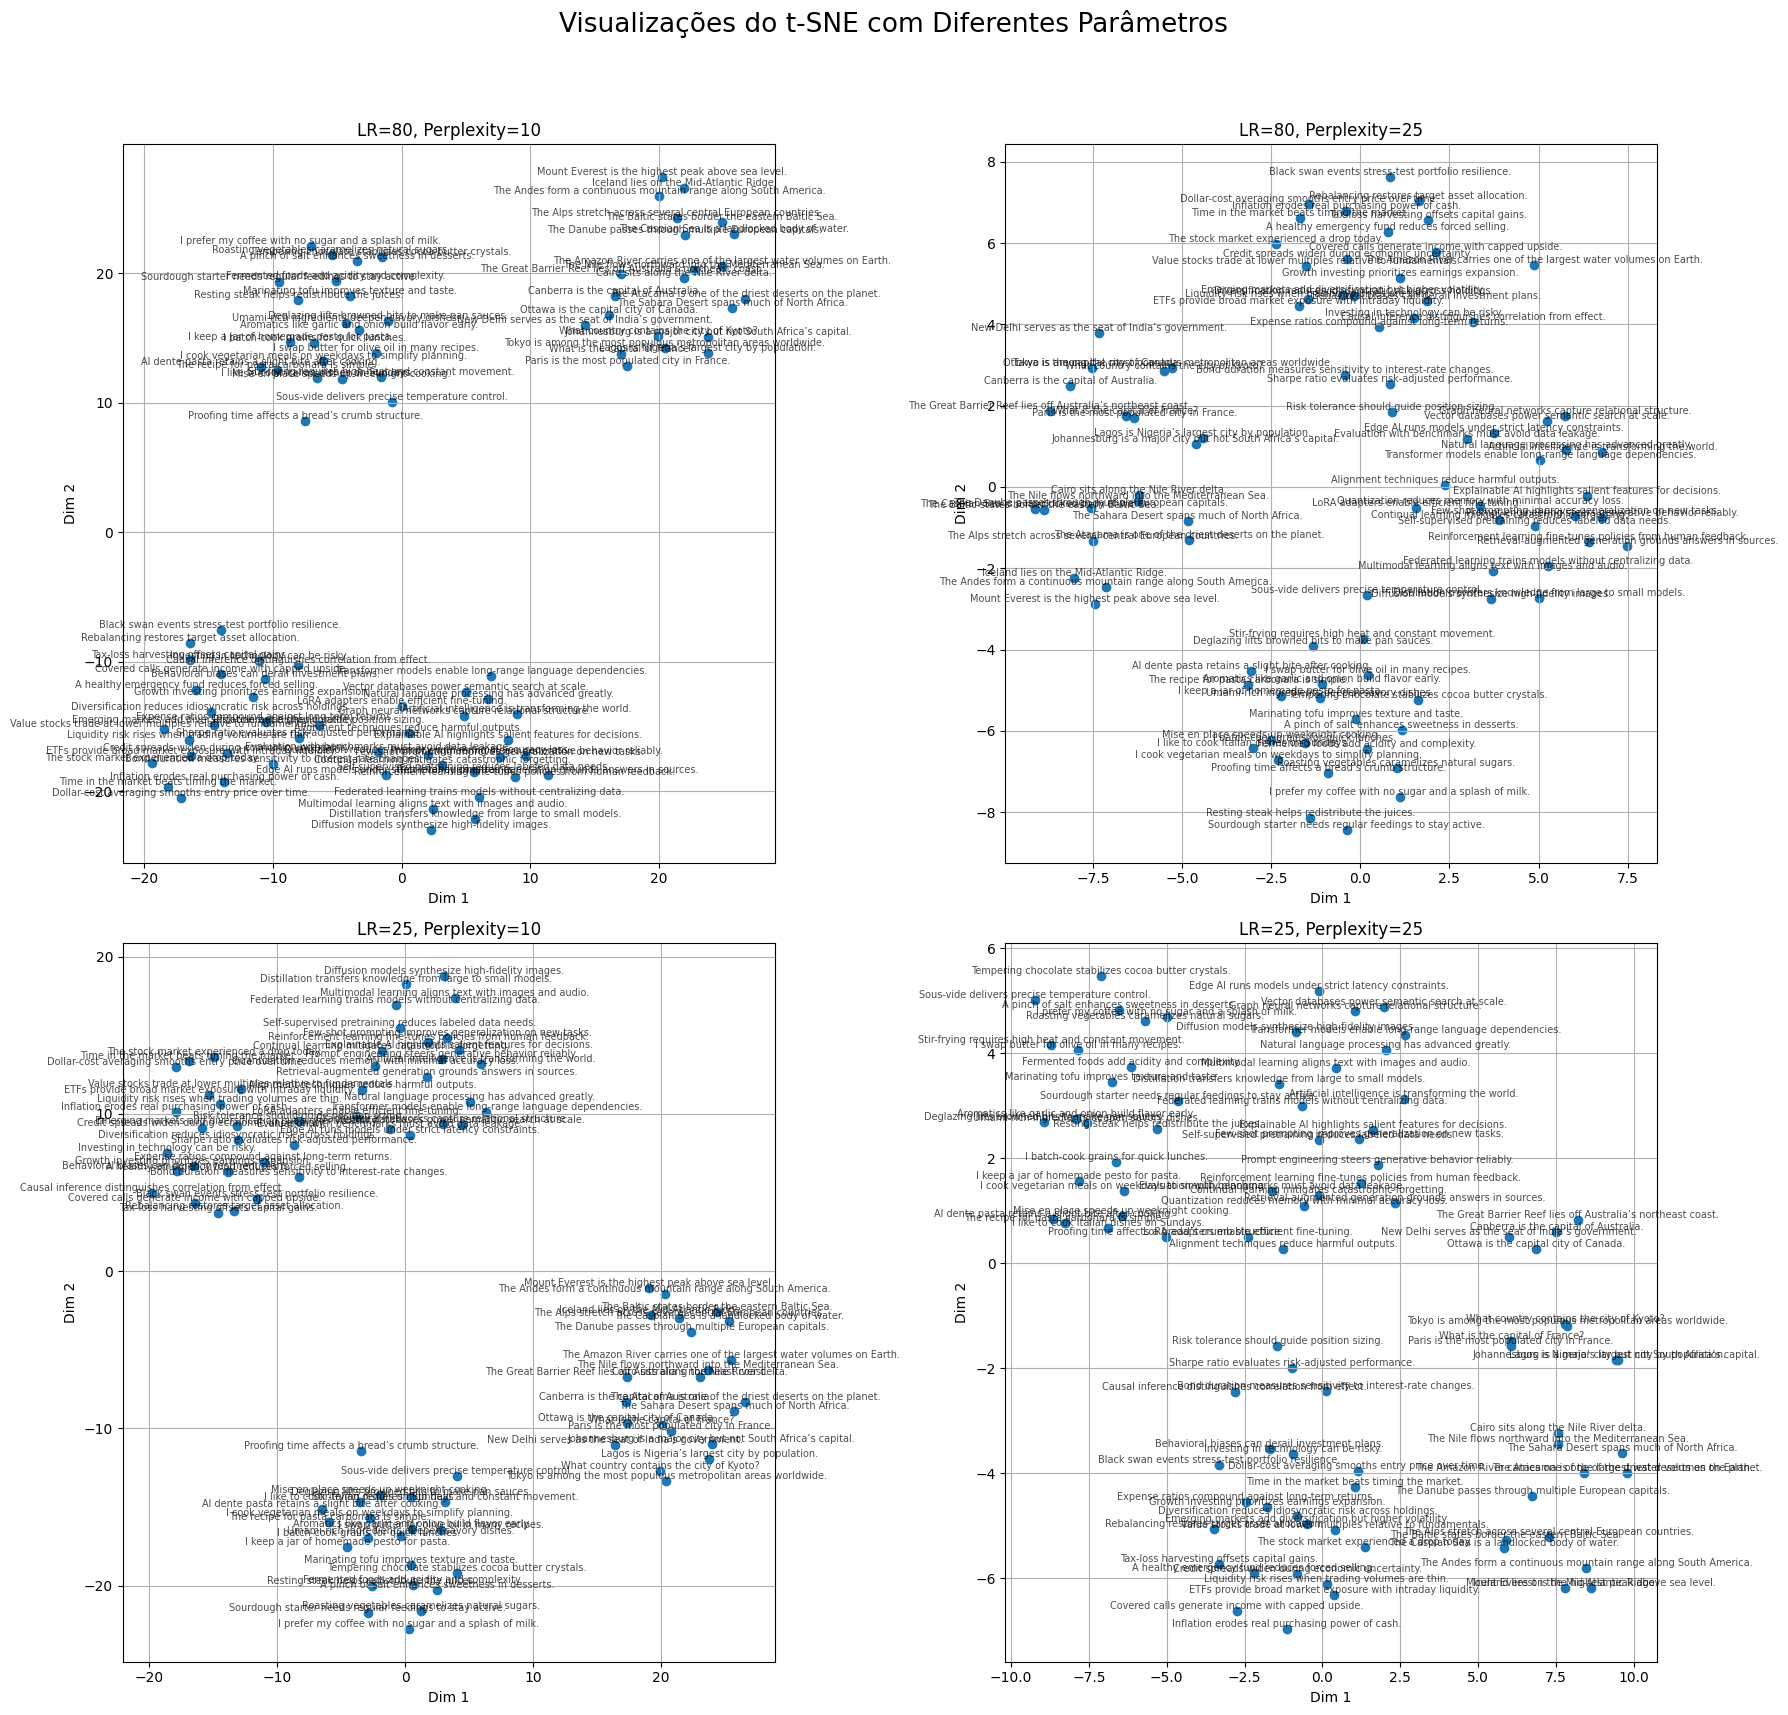

In [ ]:
from sklearn.manifold import TSNE

# parametros escolhidos
learning_rates = [80, 25]
perplexities = [10, 25]

fig, axes = plt.subplots(nrows=len(learning_rates),ncols=len(perplexities),figsize=(18, 18))

fig.suptitle('Visualizações do t-SNE com Diferentes Parâmetros', fontsize=19)

# combinação linear entre os parametros
for i, lr in enumerate(learning_rates):
    for j, perp in enumerate(perplexities):

        ax = axes[i, j]
        # t-SNE
        X_embedded = TSNE(n_components=2, learning_rate= lr, perplexity= perp ,random_state=42 ).fit_transform(X)

        ax.scatter(X_embedded[:, 0], X_embedded[:, 1])

        # legendas
        for k, (x, y) in enumerate(X_embedded):
          ax.text(x, y, sentences[k], ha='center', va='bottom', size=7, color='black', alpha=0.7, weight='normal')

        ax.set_title(f'LR={lr}, Perplexity={perp}')

        ax.set_xlabel('Dim 1')
        ax.set_ylabel('Dim 2')
        ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Analise dos resultados do t-SNE
Novamente observam-se quatro clusters bem definidos, agora com maior separação espacial entre si. Nota-se uma organização relacionada ao grau de tecnicidade das sentenças, uma vez que tópicos como culinária, natureza e geografia tendem a estar mais próximos semanticamente entre si do que em relação a conceitos mais técnicos, como finanças e aprendizado de máquina.

## UMAP

Aplique **UMAP (Uniform Manifold Approximation and Projection)** como alternativa ao t-SNE.  
O UMAP é mais eficiente, preserva parte da estrutura global e é útil para visualização e pré-processamento.

**Tarefas:**
- Gere uma projeção 2D dos embeddings com `umap.UMAP`.  
- Experimente variar `n_neighbors` e `min_dist` para observar mudanças na distribuição dos clusters.  
- Compare visualmente com os resultados do PCA e t-SNE.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


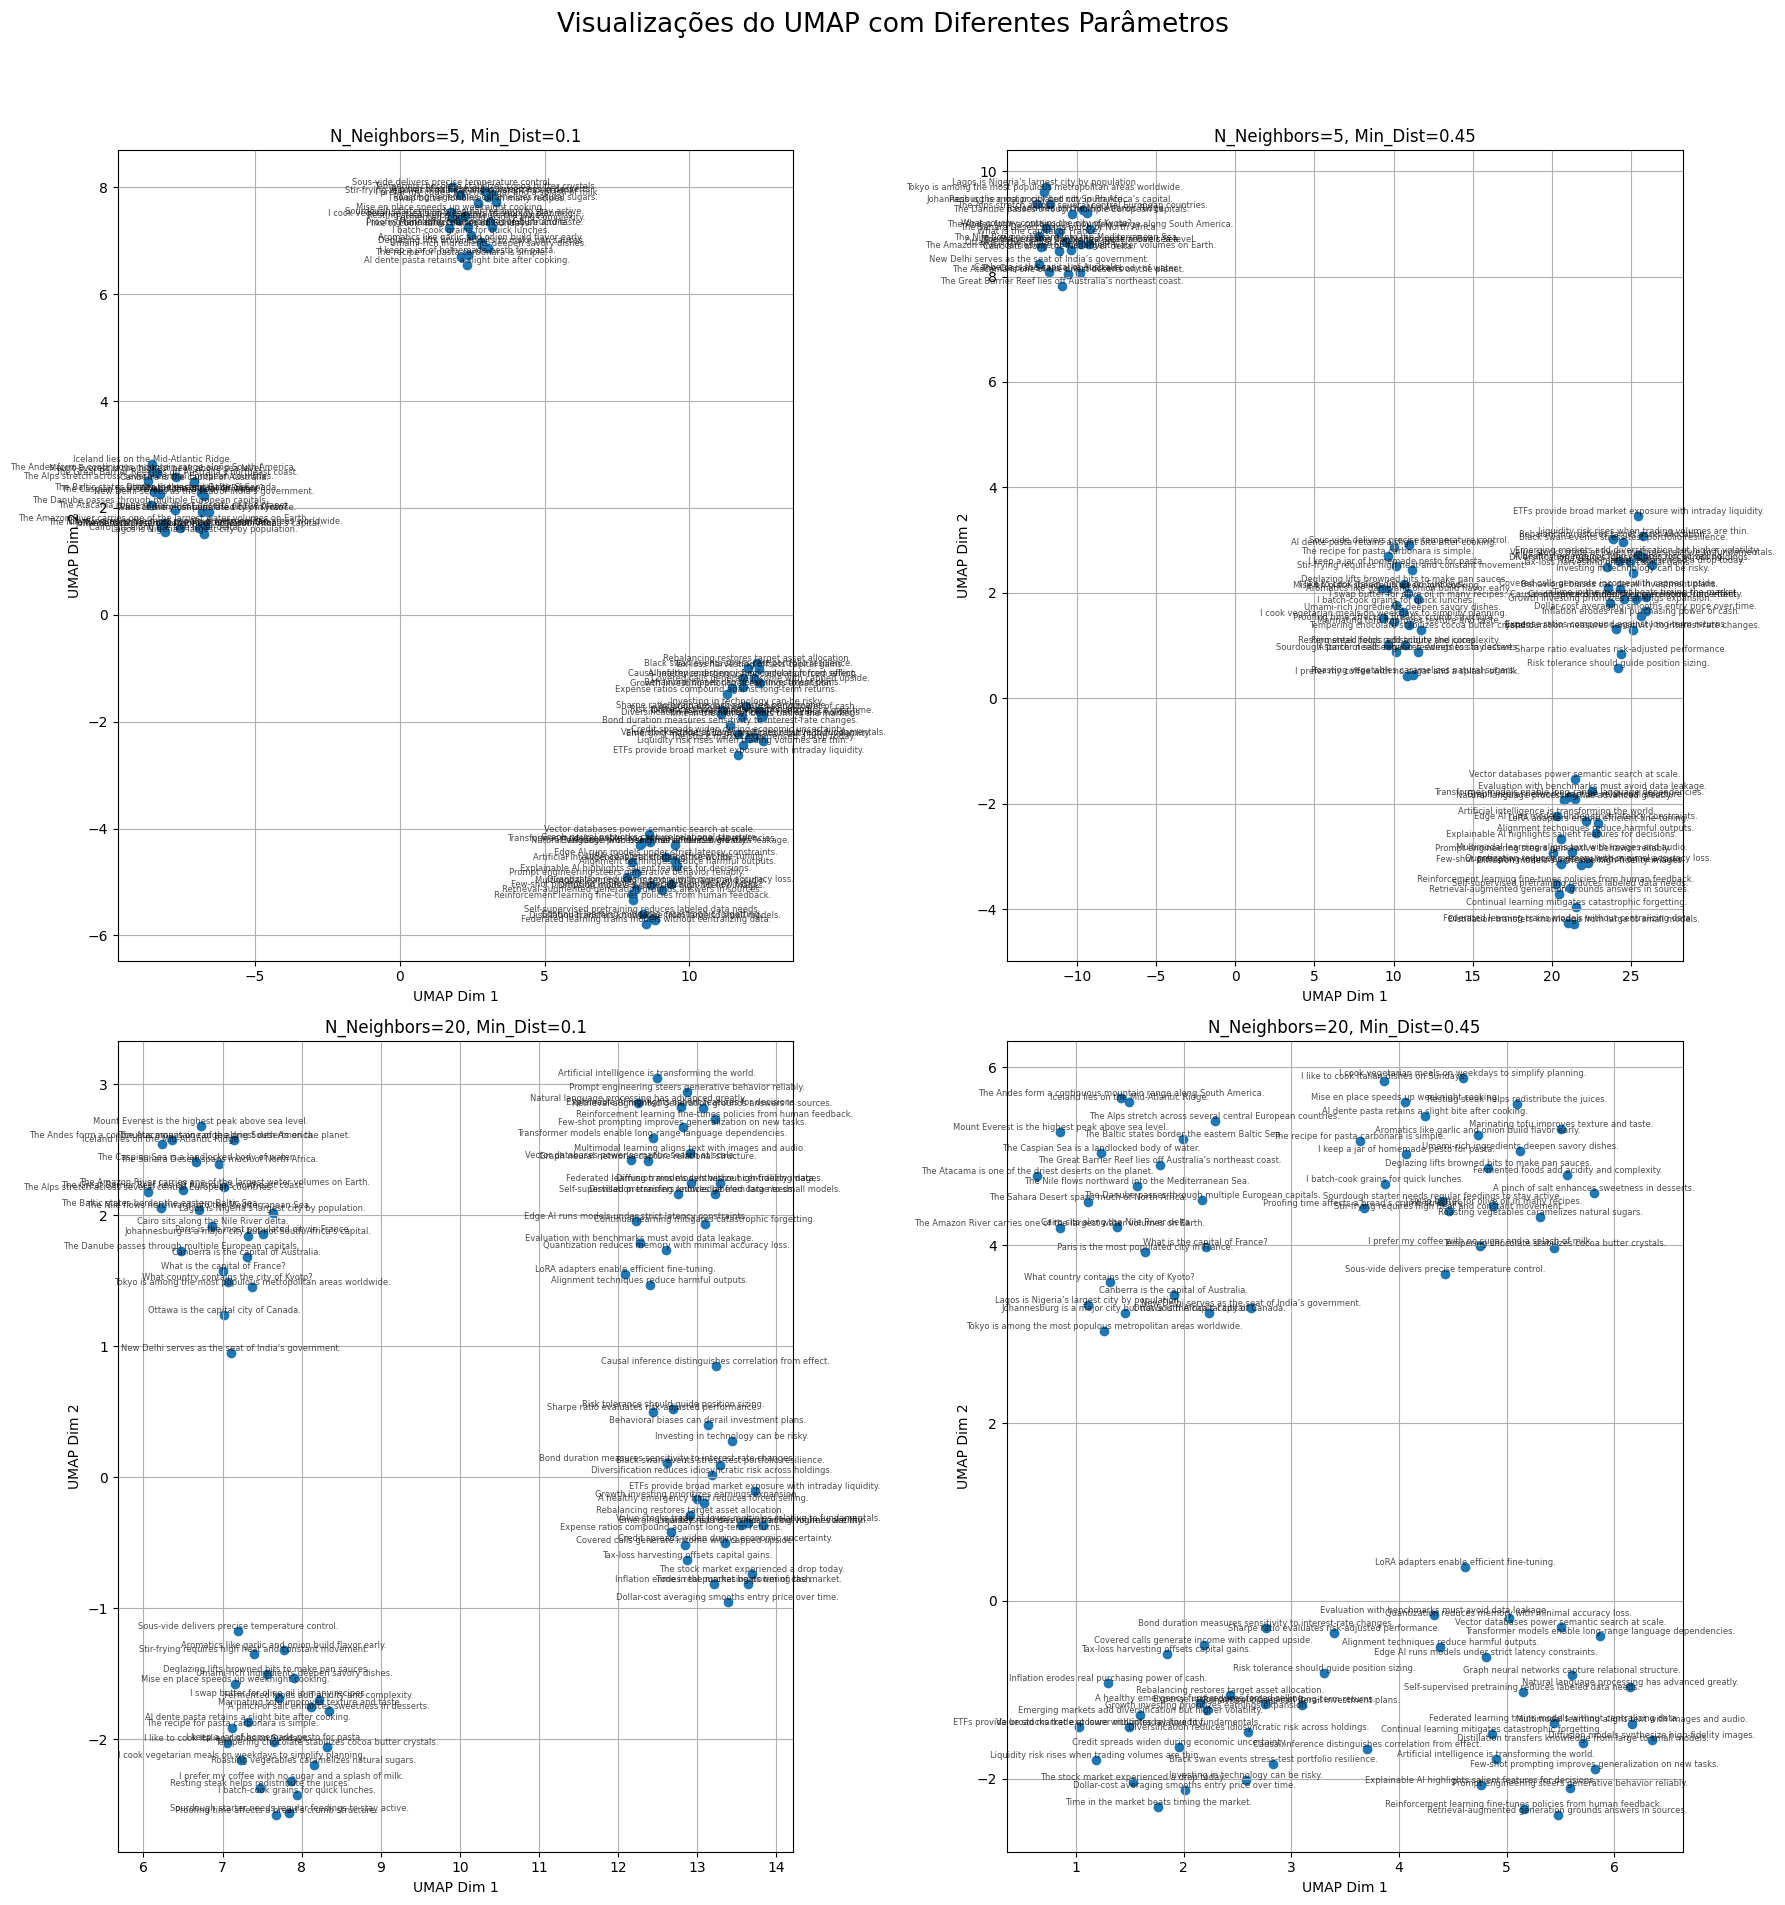

In [ ]:
import umap

# parametros escolhidos
n_neighbors = [5, 20]
min_dist = [0.1, 0.45]

fig, axes = plt.subplots(nrows=len(n_neighbors), ncols=len(min_dist), figsize=(18, 20))
fig.suptitle('Visualizações do UMAP com Diferentes Parâmetros', fontsize=19)

# combinação linear entre os parametros
for i, n_neighbor in enumerate(n_neighbors):
    for j, m_dist in enumerate(min_dist):
        ax = axes[i, j]
        # UMAP
        _umap = umap.UMAP(n_neighbors= n_neighbor, min_dist= m_dist, random_state= 42)
        X_umap = _umap.fit_transform(X)

        ax.scatter(X_umap[:, 0], X_umap[:, 1])
        # legendas
        for k, (x, y) in enumerate(X_umap):
            ax.text(x, y, sentences[k], ha='center', va='bottom', size=6, color='black', alpha=0.7, weight='normal')

        ax.set_title(f'N_Neighbors={n_neighbor}, Min_Dist={m_dist}')
        ax.set_xlabel('UMAP Dim 1')
        ax.set_ylabel('UMAP Dim 2')
        ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Comparação visual

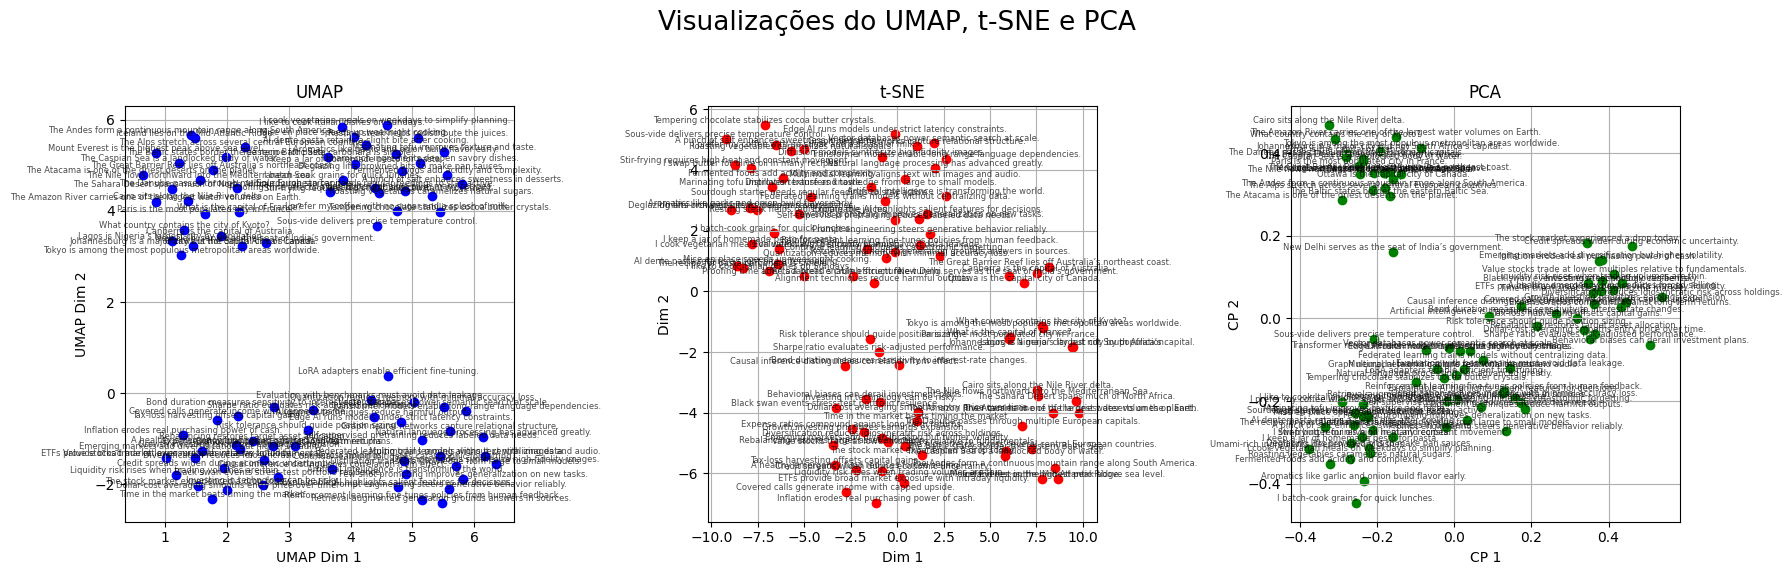

In [42]:
#plot
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
fig.suptitle('Visualizações do UMAP, t-SNE e PCA', fontsize=19)
#umap
axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c='blue')
for k, (x, y) in enumerate(X_umap):
    axes[0].text(x, y, sentences[k], ha='center', va='bottom', size=6, color='black', alpha=0.7, weight='normal')
    axes[0].set_title('UMAP')
    axes[0].set_xlabel('UMAP Dim 1')
    axes[0].set_ylabel('UMAP Dim 2')
    axes[0].grid(True)
#tsne
axes[1].scatter(X_embedded[:, 0], X_embedded[:, 1], c='red')
for k, (x, y) in enumerate(X_embedded):
    axes[1].text(x, y, sentences[k], ha='center', va='bottom', size=6, color='black', alpha=0.7, weight='normal')
    axes[1].set_title('t-SNE')
    axes[1].set_xlabel('Dim 1')
    axes[1].set_ylabel('Dim 2')
    axes[1].grid(True)
#pca
axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c='green')
for k, (x, y) in enumerate(X_pca):
    axes[2].text(x, y, sentences[k], ha='center', va='bottom', size=6, color='black', alpha=0.7, weight='normal')
    axes[2].set_title('PCA')
    axes[2].set_xlabel('CP 1')
    axes[2].set_ylabel('CP 2')
    axes[2].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Considerações Sobre o Modelo UMAP
Nota-se que o UMAP, especialmente com valores baixos de n_neighbors e min_distance, gera clusters mais compactos, bem definidos e mais espaçados entre si. Em comparação ao PCA e ao t-SNE, a separação entre os grupos torna-se mais evidente, com redução considerável da quantidade de outliers visuais.

Outro aspecto notavel é a mudança na orientação da separação temática. Enquanto no t-SNE a distinção entre conceitos mais técnicos (finanças e aprendizado de máquina) e temas mais humanísticos (culinária, geografia e natureza) ocorria predominantemente no eixo horizontal, no UMAP essa divisão passa a ocorrer no eixo vertical, com os tópicos técnicos concentrados na parte inferior do gráfico e os humanísticos na região superior.

## Classificação

Com base nas categorias observadas nos gráficos anteriores, crie uma função simples que receba um texto e classifique-o na categoria mais provável.

**Tarefas:**
- Use os embeddings existentes e os clusters identificados para rotular automaticamente cada texto.  
- Crie uma função `classificar_texto(texto: str)` que:
  1. Gere o embedding do texto.
  2. Calcule a distância para os clusters identificados.
  3. Retorne o nome do cluster mais próximo.

In [52]:
from sklearn.cluster import KMeans

def classificar_texto(texto:str):
  kmeans = KMeans(n_clusters=4, random_state=42)
  kmeans.fit(X)

  rotulos = ["Culinaria","Geografia","Finanças/Economia","Aprendizado de Maquina"]

  texto_embedding = model.encode([texto], convert_to_numpy=True)

  index_cluster = kmeans.predict(texto_embedding)[0]

  return rotulos[index_cluster]




### Testes da função classificar_texto

In [53]:
test_sentences = [
    "The recipe requires fresh basil, garlic, and olive oil to make the sauce.",
    "Mount Everest is the highest mountain above sea level on Earth.",
    "Neural networks can learn complex patterns from large datasets.",
    "Rising interest rates often influence stock market performance.",
    "Baking bread involves fermentation and careful temperature control.",
    "Exchange-traded funds provide investors with diversified exposure to markets."
]

for sentence in test_sentences:
  print(f"Texto: {sentence}\nCategoria: {classificar_texto(sentence)}\n")

Texto: The recipe requires fresh basil, garlic, and olive oil to make the sauce.
Categoria: Culinaria

Texto: Mount Everest is the highest mountain above sea level on Earth.
Categoria: Geografia

Texto: Neural networks can learn complex patterns from large datasets.
Categoria: Aprendizado de Maquina

Texto: Rising interest rates often influence stock market performance.
Categoria: Finanças/Economia

Texto: Baking bread involves fermentation and careful temperature control.
Categoria: Culinaria

Texto: Exchange-traded funds provide investors with diversified exposure to markets.
Categoria: Finanças/Economia

